# Soil Fertility Score Regression
Predicts `fertility_score` using 15 models with the correct evaluation methodology:
1. Split data into train (80%) and test (20%) **first**
2. Apply 5-fold CV **only on the train set** for model comparison
3. Report per-fold CV scores for transparency
4. Evaluate the best model **once** on the held-out test set for final unbiased performance

## Imports & paths


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor,
    AdaBoostRegressor, BaggingRegressor
)
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import probplot
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings, os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
np.random.seed(42)

ZONED_PATH = 'soil_zoned.csv'
OUT_DIR    = 'outputs'
os.makedirs(OUT_DIR, exist_ok=True)

## Load data & define features

In [3]:
soil = pd.read_csv(ZONED_PATH)

FEATURES = [
    'nitrogen_total_scaled', 'phosphorus_avail_scaled', 'potassium_exch_scaled',
    'pH_water_scaled', 'organic_carbon_scaled', 'sand_percent_scaled',
    'silt_percent_scaled', 'clay_percent_scaled', 'bulk_density_scaled',
    'cation_exchange_cap_scaled', 'NDVI_mean_scaled', 'NDVI_std_scaled',
    'rainfall_annual_scaled', 'altitude_scaled', 'NPK_total_scaled',
    'N_to_P_scaled', 'N_to_K_scaled', 'P_to_K_scaled',
    'pH_category_encoded_scaled', 'texture_encoded_scaled',
    'landcover_encoded_scaled', 'sampling_year_scaled',
    'sampling_month_scaled', 'country_encoded_scaled'
]
FEATURE_NAMES = [f.replace('_scaled', '') for f in FEATURES]
TARGET = 'fertility_score'

soil_model = soil.dropna(subset=[TARGET] + FEATURES).reset_index(drop=True)
X = soil_model[FEATURES].values
y = soil_model[TARGET].values

print(f'Full dataset  : {X.shape[0]} rows x {X.shape[1]} features')
print(f'Target range  : {y.min():.2f} to {y.max():.2f}  (mean={y.mean():.2f})')

Full dataset  : 5000 rows x 24 features
Target range  : 10.99 to 91.06  (mean=48.97)


## Train / test split
The test set is locked away and **not touched** until the final evaluation step.

In [4]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, np.arange(len(y)), test_size=0.2, random_state=42
)

print(f'Train set : {len(X_train)} samples (80%)')
print(f'Test set  : {len(X_test)} samples (20%)  <- locked until final evaluation')

Train set : 4000 samples (80%)
Test set  : 1000 samples (20%)  <- locked until final evaluation


## Target variable analysis

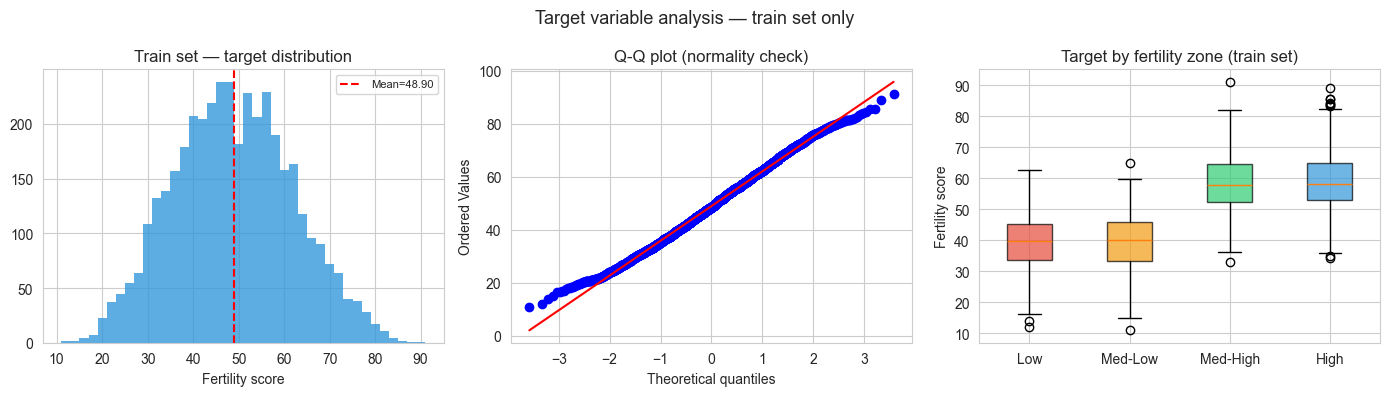

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(y_train, bins=40, color='#3498db', edgecolor='none', alpha=0.8)
axes[0].axvline(y_train.mean(), color='red', linestyle='--', label=f'Mean={y_train.mean():.2f}')
axes[0].set_title('Train set — target distribution')
axes[0].set_xlabel('Fertility score')
axes[0].legend(fontsize=8)

probplot(y_train, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot (normality check)')

zone_order  = ['Low fertility', 'Medium-low fertility', 'Medium-high fertility', 'High fertility']
zone_colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
train_df    = soil_model.iloc[idx_train]
data_by_zone = [train_df[train_df['zone_label'] == z][TARGET].values for z in zone_order]
bp = axes[2].boxplot(data_by_zone, patch_artist=True, labels=['Low','Med-Low','Med-High','High'])
for patch, color in zip(bp['boxes'], zone_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[2].set_title('Target by fertility zone (train set)')
axes[2].set_ylabel('Fertility score')

plt.suptitle('Target variable analysis — train set only', fontsize=13)
plt.tight_layout()
plt.show()

## Define all 15 models

In [6]:
MODELS = {
    'Ridge'         : Ridge(alpha=1.0),
    'Lasso'         : Lasso(alpha=0.1),
    'ElasticNet'    : ElasticNet(alpha=0.1, l1_ratio=0.5),
    'KNN'           : KNeighborsRegressor(n_neighbors=7),
    'SVR'           : SVR(kernel='rbf', C=10, epsilon=0.1),
    'Decision Tree' : DecisionTreeRegressor(max_depth=6, random_state=42),
    'Bagging'       : BaggingRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Random Forest' : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees'   : ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'AdaBoost'      : AdaBoostRegressor(n_estimators=100, random_state=42),
    'Gradient Boost': GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42),
    'XGBoost'       : XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, verbosity=0, n_jobs=-1),
    'LightGBM'      : LGBMRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost'      : CatBoostRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, verbose=0),
    'ANN (MLP)'     : MLPRegressor(hidden_layer_sizes=(128,64,32), activation='relu', max_iter=500,
                                    random_state=42, early_stopping=True, validation_fraction=0.1),
}
print(f'{len(MODELS)} models defined.')

15 models defined.


## 5. 5-fold CV on train set (per-fold results)
CV is applied **only on the train set**. Each fold's validation scores are recorded individually.

In [7]:
kf          = KFold(n_splits=5, shuffle=True, random_state=42)
cv_summary  = []
fold_records = []

for name, model in MODELS.items():
    cv = cross_validate(
        model, X_train, y_train, cv=kf,
        scoring={'r2':'r2', 'rmse':'neg_root_mean_squared_error', 'mae':'neg_mean_absolute_error'},
        return_train_score=True
    )
    # Per-fold records
    for i in range(5):
        fold_records.append({
            'Model'    : name,
            'Fold'     : i + 1,
            'Val_R2'   : round(cv['test_r2'][i], 4),
            'Val_RMSE' : round(-cv['test_rmse'][i], 4),
            'Val_MAE'  : round(-cv['test_mae'][i], 4),
            'Train_R2' : round(cv['train_r2'][i], 4),
        })
    # Summary
    cv_summary.append({
        'Model'    : name,
        'CV_R2'    : round(cv['test_r2'].mean(), 4),
        'CV_R2_std': round(cv['test_r2'].std(), 4),
        'CV_RMSE'  : round(-cv['test_rmse'].mean(), 4),
        'CV_MAE'   : round(-cv['test_mae'].mean(), 4),
        'Train_R2' : round(cv['train_r2'].mean(), 4),
        'Overfit'  : round(cv['train_r2'].mean() - cv['test_r2'].mean(), 4),
    })
    print(f"  {name:<18} CV_R2={cv_summary[-1]['CV_R2']:.4f} +/- {cv_summary[-1]['CV_R2_std']:.4f}  "
          f"RMSE={cv_summary[-1]['CV_RMSE']:.4f}  overfit={cv_summary[-1]['Overfit']:.4f}")

cv_df   = pd.DataFrame(cv_summary).sort_values('CV_R2', ascending=False).reset_index(drop=True)
fold_df = pd.DataFrame(fold_records)

  Ridge              CV_R2=0.8863 +/- 0.0069  RMSE=4.4133  overfit=0.0018
  Lasso              CV_R2=0.8864 +/- 0.0062  RMSE=4.4106  overfit=0.0008
  ElasticNet         CV_R2=0.8860 +/- 0.0063  RMSE=4.4184  overfit=0.0012
  KNN                CV_R2=0.8106 +/- 0.0065  RMSE=5.6964  overfit=0.0495
  SVR                CV_R2=0.9008 +/- 0.0047  RMSE=4.1222  overfit=0.0522
  Decision Tree      CV_R2=0.8075 +/- 0.0128  RMSE=5.7395  overfit=0.0571
  Bagging            CV_R2=0.9014 +/- 0.0062  RMSE=4.1087  overfit=0.0847
  Random Forest      CV_R2=0.9012 +/- 0.0061  RMSE=4.1130  overfit=0.0849
  Extra Trees        CV_R2=0.9079 +/- 0.0039  RMSE=3.9732  overfit=0.0921
  AdaBoost           CV_R2=0.8769 +/- 0.0024  RMSE=4.5940  overfit=0.0147
  Gradient Boost     CV_R2=0.9199 +/- 0.0037  RMSE=3.7042  overfit=0.0491
  XGBoost            CV_R2=0.9195 +/- 0.0043  RMSE=3.7115  overfit=0.0489
  LightGBM           CV_R2=0.9197 +/- 0.0046  RMSE=3.7080  overfit=0.0446
  CatBoost           CV_R2=0.9276 +/- 

## Per-fold results table

In [8]:
# Pivot to wide format: model x fold
fold_pivot = fold_df.pivot(index='Model', columns='Fold', values='Val_R2')
fold_pivot.columns = [f'Fold {i}' for i in fold_pivot.columns]
fold_pivot['Mean'] = fold_pivot.mean(axis=1).round(4)
fold_pivot['Std']  = fold_pivot.std(axis=1).round(4)
fold_pivot = fold_pivot.sort_values('Mean', ascending=False)

print('Per-fold validation R2 (CV on train set only):')
print(fold_pivot.round(4).to_string())

Per-fold validation R2 (CV on train set only):
                Fold 1  Fold 2  Fold 3  Fold 4  Fold 5    Mean     Std
Model                                                                 
CatBoost        0.9313  0.9275  0.9264  0.9319  0.9211  0.9276  0.0039
Gradient Boost  0.9238  0.9203  0.9213  0.9211  0.9129  0.9199  0.0037
LightGBM        0.9238  0.9165  0.9214  0.9245  0.9124  0.9197  0.0046
XGBoost         0.9235  0.9201  0.9205  0.9223  0.9113  0.9195  0.0043
Extra Trees     0.9080  0.9078  0.9125  0.9102  0.9008  0.9079  0.0039
ANN (MLP)       0.9113  0.9140  0.9073  0.9080  0.8929  0.9067  0.0073
Bagging         0.9060  0.8991  0.9066  0.9051  0.8902  0.9014  0.0062
Random Forest   0.9064  0.8986  0.9061  0.9045  0.8903  0.9012  0.0061
SVR             0.8992  0.9009  0.9075  0.9033  0.8932  0.9008  0.0047
Lasso           0.8869  0.8850  0.8891  0.8951  0.8760  0.8864  0.0062
Ridge           0.8871  0.8852  0.8889  0.8956  0.8744  0.8862  0.0069
ElasticNet      0.8868  0.8845

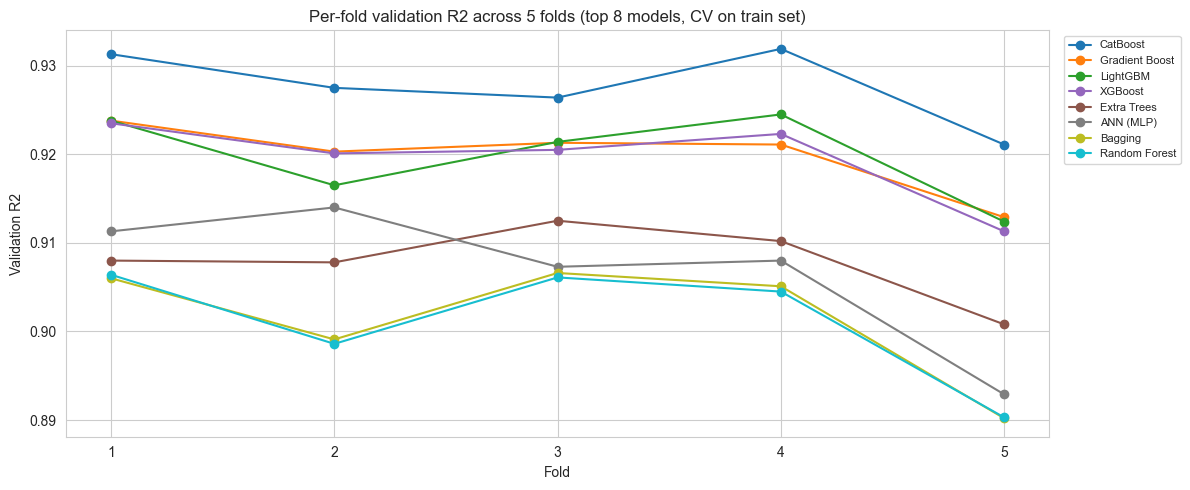

In [9]:
# Visualise per-fold R2 stability
top_models = cv_df['Model'].head(8).tolist()
fold_top   = fold_df[fold_df['Model'].isin(top_models)]

fig, ax = plt.subplots(figsize=(12, 5))
colors_map = plt.cm.tab10(np.linspace(0, 1, len(top_models)))

for color, name in zip(colors_map, top_models):
    sub = fold_top[fold_top['Model'] == name]
    ax.plot(sub['Fold'], sub['Val_R2'], marker='o', label=name, color=color, linewidth=1.5)

ax.set_xlabel('Fold')
ax.set_ylabel('Validation R2')
ax.set_xticks([1,2,3,4,5])
ax.set_title('Per-fold validation R2 across 5 folds (top 8 models, CV on train set)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## CV summary table & visual comparison

In [10]:
print('CV summary (sorted by CV_R2, evaluated on train set only):')
print(cv_df.to_string(index=False))

CV summary (sorted by CV_R2, evaluated on train set only):
         Model  CV_R2  CV_R2_std  CV_RMSE  CV_MAE  Train_R2  Overfit
      CatBoost 0.9276     0.0039   3.5196  2.7481    0.9450   0.0174
Gradient Boost 0.9199     0.0037   3.7042  2.8924    0.9690   0.0491
      LightGBM 0.9197     0.0046   3.7080  2.8922    0.9643   0.0446
       XGBoost 0.9195     0.0043   3.7115  2.8949    0.9684   0.0489
   Extra Trees 0.9079     0.0039   3.9732  3.1071    1.0000   0.0921
     ANN (MLP) 0.9067     0.0073   3.9944  3.1250    0.9457   0.0390
       Bagging 0.9014     0.0062   4.1087  3.2106    0.9861   0.0847
 Random Forest 0.9012     0.0061   4.1130  3.2131    0.9861   0.0849
           SVR 0.9008     0.0047   4.1222  3.2068    0.9530   0.0522
         Lasso 0.8864     0.0062   4.4106  3.5187    0.8872   0.0008
         Ridge 0.8863     0.0069   4.4133  3.5172    0.8880   0.0018
    ElasticNet 0.8860     0.0063   4.4184  3.5214    0.8872   0.0012
      AdaBoost 0.8769     0.0024   4.5940  3

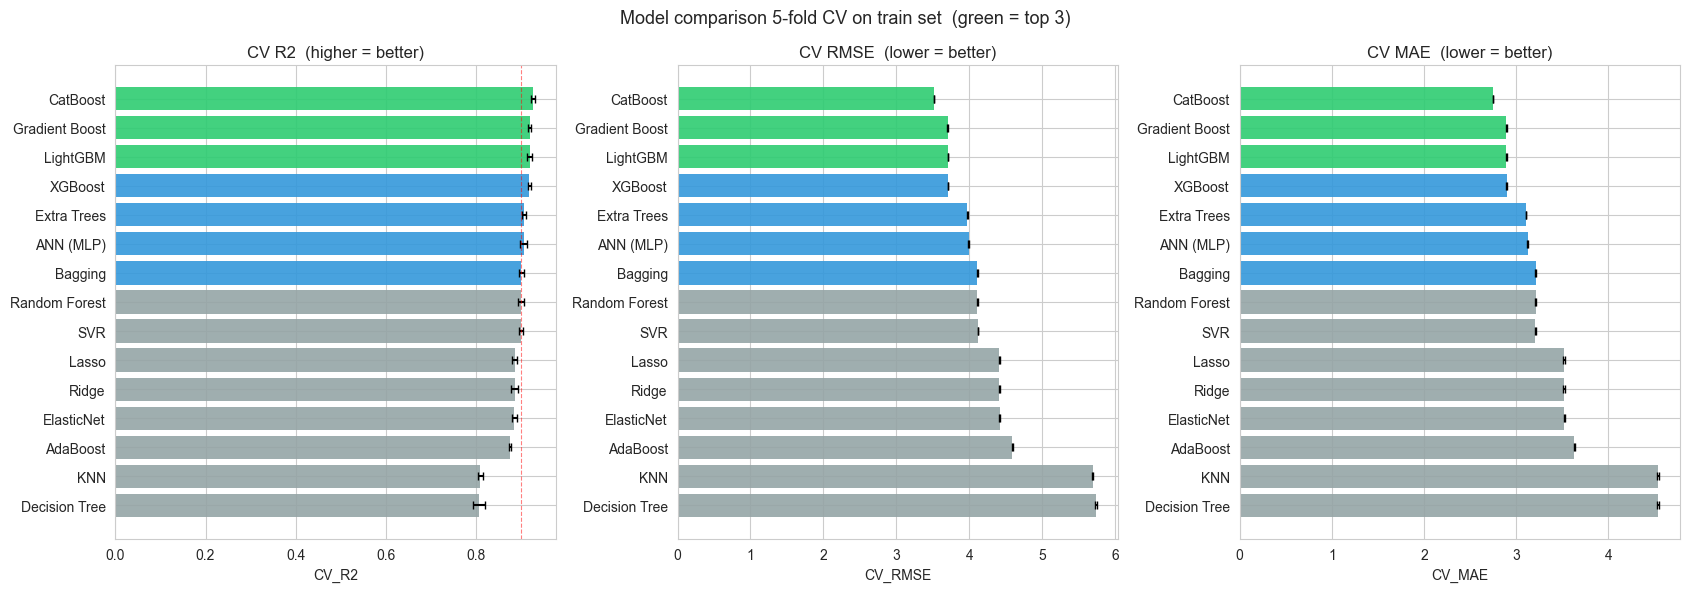

In [11]:
n = len(cv_df)
colors = ['#2ecc71' if i < 3 else '#3498db' if i < n//2 else '#95a5a6' for i in range(n)]

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
for ax, metric, err, title in [
    (axes[0], 'CV_R2',  'CV_R2_std', 'CV R2  (higher = better)'),
    (axes[1], 'CV_RMSE', 'CV_R2_std', 'CV RMSE  (lower = better)'),
    (axes[2], 'CV_MAE',  'CV_R2_std', 'CV MAE  (lower = better)'),
]:
    ax.barh(cv_df['Model'][::-1], cv_df[metric][::-1],
            xerr=cv_df['CV_R2_std'][::-1], color=colors[::-1],
            edgecolor='none', capsize=3, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel(metric)

axes[0].axvline(0.9, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
plt.suptitle('Model comparison 5-fold CV on train set  (green = top 3)', fontsize=13)
plt.tight_layout()
plt.show()

## Bias-variance analysis (train vs CV validation R2)

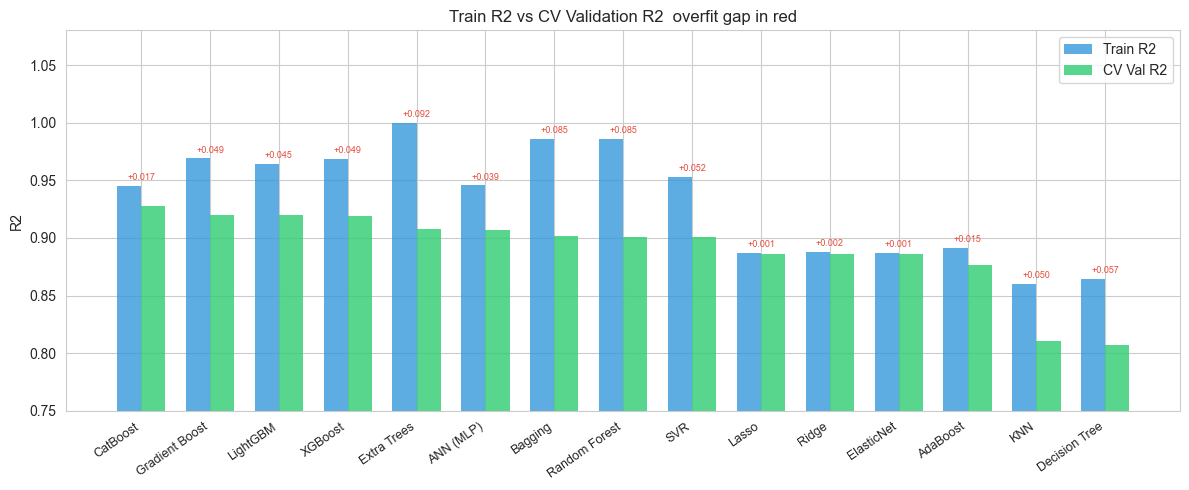

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(cv_df))
width = 0.35

ax.bar(x_pos - width/2, cv_df['Train_R2'], width, label='Train R2', color='#3498db', alpha=0.8, edgecolor='none')
ax.bar(x_pos + width/2, cv_df['CV_R2'],    width, label='CV Val R2', color='#2ecc71', alpha=0.8, edgecolor='none')

for i, row in cv_df.iterrows():
    ax.text(i, max(row['Train_R2'], row['CV_R2']) + 0.005,
            f"+{row['Overfit']:.3f}", ha='center', fontsize=6.5, color='#e74c3c')

ax.set_xticks(x_pos)
ax.set_xticklabels(cv_df['Model'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('R2')
ax.set_ylim(0.75, 1.08)
ax.set_title('Train R2 vs CV Validation R2  overfit gap in red')
ax.legend()
plt.tight_layout()
plt.show()

## Final evaluation on held-out test set
The best model (CatBoost) is retrained on the **full train set** and evaluated **once** on the held-out test set. This is the unbiased final performance estimate.

In [13]:
BEST_NAME  = cv_df.iloc[0]['Model']
BEST_MODEL = CatBoostRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, verbose=0
)

BEST_MODEL.fit(X_train, y_train)
y_pred    = BEST_MODEL.predict(X_test)
residuals = y_test - y_pred

test_r2   = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae  = mean_absolute_error(y_test, y_pred)

print(f'Best model (by CV R2): {BEST_NAME}')
print(f'\nFinal held-out test set performance (n={len(y_test)}):')
print(f'  R2   = {test_r2:.4f}')
print(f'  RMSE = {test_rmse:.4f}')
print(f'  MAE  = {test_mae:.4f}')
print(f'\nCV R2 (train set)  : {cv_df.iloc[0]["CV_R2"]:.4f} +/- {cv_df.iloc[0]["CV_R2_std"]:.4f}')
print(f'Test R2 (held-out) : {test_r2:.4f}')

Best model (by CV R2): CatBoost

Final held-out test set performance (n=1000):
  R2   = 0.9154
  RMSE = 3.7365
  MAE  = 2.9304

CV R2 (train set)  : 0.9276 +/- 0.0039
Test R2 (held-out) : 0.9154


In [14]:
# Also evaluate all models on test set for full comparison table
test_results = []
for name, model in MODELS.items():
    model.fit(X_train, y_train)
    yp = model.predict(X_test)
    test_results.append({
        'Model'    : name,
        'CV_R2'    : cv_df[cv_df['Model']==name]['CV_R2'].values[0],
        'Test_R2'  : round(r2_score(y_test, yp), 4),
        'Test_RMSE': round(np.sqrt(mean_squared_error(y_test, yp)), 4),
        'Test_MAE' : round(mean_absolute_error(y_test, yp), 4),
    })

test_df = pd.DataFrame(test_results).sort_values('CV_R2', ascending=False).reset_index(drop=True)
print('CV R2 vs Test R2 for all models:')
print(test_df.to_string(index=False))

CV R2 vs Test R2 for all models:
         Model  CV_R2  Test_R2  Test_RMSE  Test_MAE
      CatBoost 0.9276   0.9154     3.7365    2.9304
Gradient Boost 0.9199   0.9087     3.8826    3.0741
      LightGBM 0.9197   0.9089     3.8777    3.0855
       XGBoost 0.9195   0.9072     3.9130    3.1015
   Extra Trees 0.9079   0.8970     4.1232    3.2507
     ANN (MLP) 0.9067   0.8954     4.1556    3.3193
       Bagging 0.9014   0.8910     4.2420    3.3486
 Random Forest 0.9012   0.8912     4.2382    3.3468
           SVR 0.9008   0.8939     4.1859    3.3011
         Lasso 0.8864   0.8702     4.6289    3.7001
         Ridge 0.8863   0.8707     4.6192    3.7000
    ElasticNet 0.8860   0.8698     4.6354    3.7103
      AdaBoost 0.8769   0.8586     4.8306    3.8497
           KNN 0.8106   0.8037     5.6932    4.5524
 Decision Tree 0.8075   0.7869     5.9310    4.7119


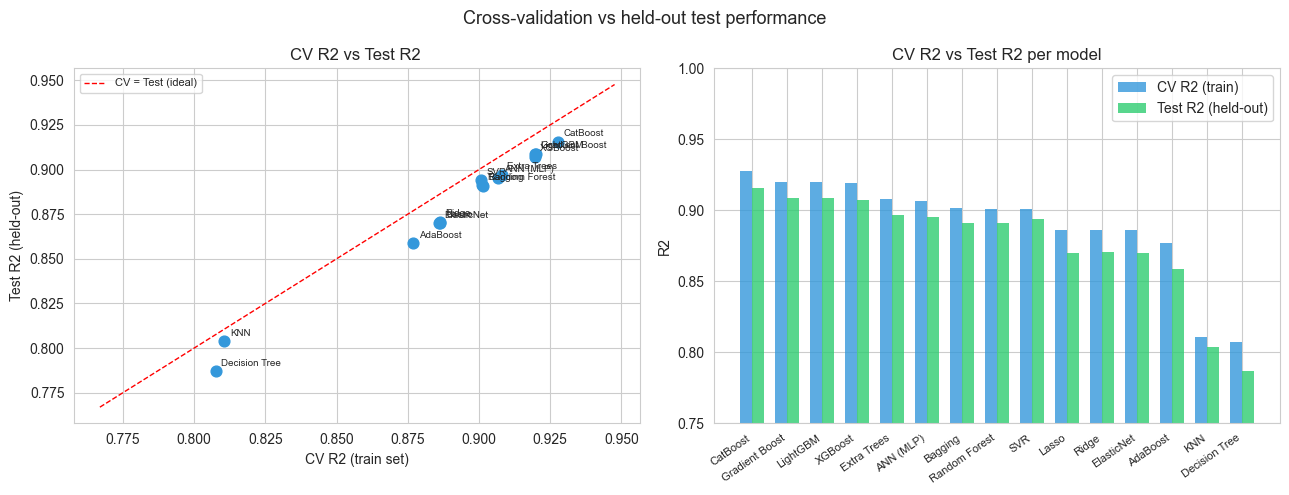

In [15]:
# CV R2 vs Test R2 scatter — ideal: points lie on the diagonal
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(test_df['CV_R2'], test_df['Test_R2'], color='#3498db', s=60, zorder=3)
for _, row in test_df.iterrows():
    axes[0].annotate(row['Model'], (row['CV_R2'], row['Test_R2']),
                     fontsize=7, xytext=(4,4), textcoords='offset points')
lims = [min(test_df['CV_R2'].min(), test_df['Test_R2'].min()) - 0.02,
        max(test_df['CV_R2'].max(), test_df['Test_R2'].max()) + 0.02]
axes[0].plot(lims, lims, 'r--', linewidth=1, label='CV = Test (ideal)')
axes[0].set_xlabel('CV R2 (train set)')
axes[0].set_ylabel('Test R2 (held-out)')
axes[0].set_title('CV R2 vs Test R2 ')
axes[0].legend(fontsize=8)

# Grouped bar: CV vs Test R2 for all models
x_pos = np.arange(len(test_df))
width = 0.35
axes[1].bar(x_pos - width/2, test_df['CV_R2'],   width, label='CV R2 (train)',    color='#3498db', alpha=0.8, edgecolor='none')
axes[1].bar(x_pos + width/2, test_df['Test_R2'],  width, label='Test R2 (held-out)', color='#2ecc71', alpha=0.8, edgecolor='none')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(test_df['Model'], rotation=35, ha='right', fontsize=8)
axes[1].set_ylabel('R2')
axes[1].set_ylim(0.75, 1.0)
axes[1].set_title('CV R2 vs Test R2 per model')
axes[1].legend()

plt.suptitle('Cross-validation vs held-out test performance', fontsize=13)
plt.tight_layout()
plt.show()

## Residual analysis (best model on test set)

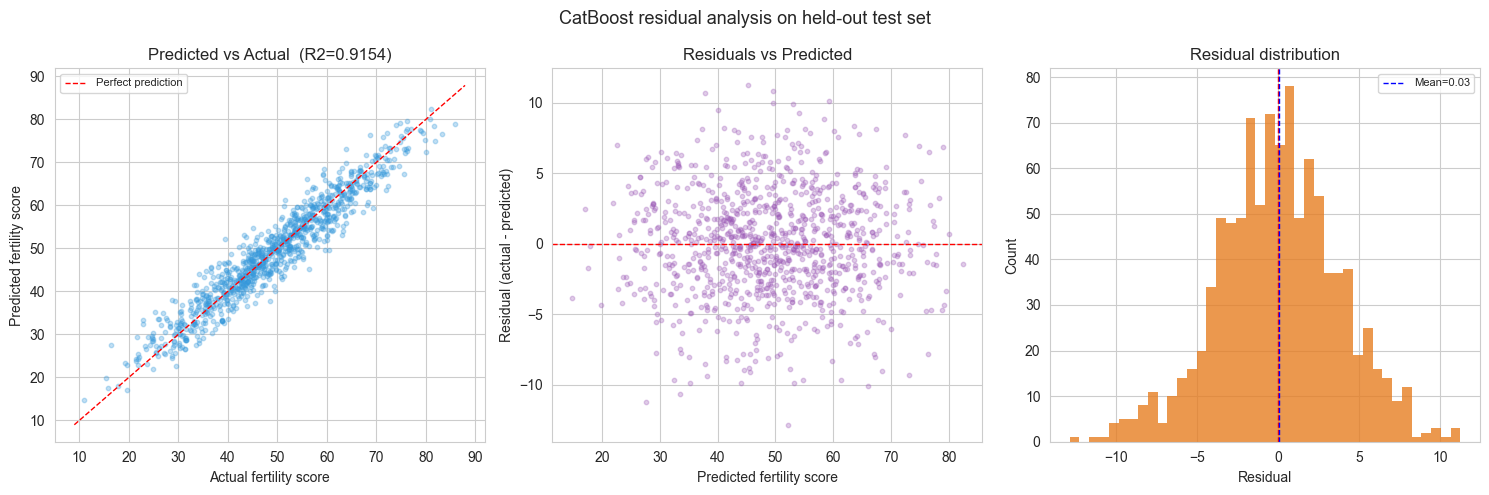

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='#3498db')
lims = [min(y_test.min(), y_pred.min())-2, max(y_test.max(), y_pred.max())+2]
axes[0].plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel('Actual fertility score')
axes[0].set_ylabel('Predicted fertility score')
axes[0].set_title(f'Predicted vs Actual  (R2={test_r2:.4f})')
axes[0].legend(fontsize=8)

axes[1].scatter(y_pred, residuals, alpha=0.3, s=10, color='#9b59b6')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted fertility score')
axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].set_title('Residuals vs Predicted')

axes[2].hist(residuals, bins=40, color='#e67e22', edgecolor='none', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1)
axes[2].axvline(residuals.mean(), color='blue', linestyle='--',
                linewidth=1, label=f'Mean={residuals.mean():.2f}')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')
axes[2].set_title('Residual distribution')
axes[2].legend(fontsize=8)

plt.suptitle(f'{BEST_NAME} residual analysis on held-out test set', fontsize=13)
plt.tight_layout()
plt.show()

## Feature importance

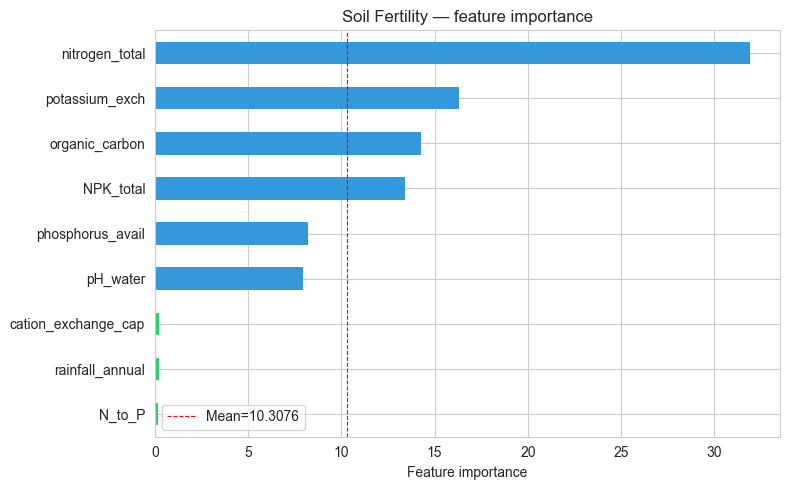

In [17]:
# Feature importance — top 9 numerical features only

NUMERICAL_FEATURES = [
    'nitrogen_total',
    'potassium_exch',
    'organic_carbon',
    'NPK_total',
    'phosphorus_avail',
    'pH_water',
    'cation_exchange_cap',
    'rainfall_annual',
    'N_to_P'
]

# Get indices of selected features
num_idx = [FEATURE_NAMES.index(f) for f in NUMERICAL_FEATURES]

# Extract importances
importances = pd.Series(
    BEST_MODEL.feature_importances_[num_idx],
    index=NUMERICAL_FEATURES
).sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

colors_imp = [
    '#2ecc71' if i < 3 else '#3498db'
    for i in range(len(importances))
]

importances.plot(
    kind='barh',
    ax=ax,
    color=colors_imp[::-1],
    edgecolor='none'
)

ax.invert_yaxis()

ax.set_xlabel('Feature importance')
ax.set_title('Soil Fertility — feature importance')

ax.axvline(
    importances.mean(),
    color='red',
    linestyle='--',
    linewidth=0.8,
    label=f'Mean={importances.mean():.4f}'
)

ax.legend()
plt.tight_layout()
plt.show()

## Per-zone performance on test set

In [18]:
zone_order  = ['Low fertility','Medium-low fertility','Medium-high fertility','High fertility']
zone_colors = {'Low fertility':'#e74c3c','Medium-low fertility':'#f39c12',
               'Medium-high fertility':'#2ecc71','High fertility':'#3498db'}

test_df_pred = soil_model.iloc[idx_test].copy().reset_index(drop=True)
test_df_pred['y_pred']   = y_pred
test_df_pred['residual'] = residuals

zone_metrics = []
for zone in zone_order:
    sub = test_df_pred[test_df_pred['zone_label'] == zone]
    if len(sub) == 0: continue
    zone_metrics.append({
        'Zone' : zone, 'n': len(sub),
        'R2'   : round(r2_score(sub['fertility_score'], sub['y_pred']), 4),
        'RMSE' : round(np.sqrt(mean_squared_error(sub['fertility_score'], sub['y_pred'])), 4),
        'MAE'  : round(mean_absolute_error(sub['fertility_score'], sub['y_pred']), 4),
        'Bias' : round(sub['residual'].mean(), 4),
    })

print(pd.DataFrame(zone_metrics).to_string(index=False))

                 Zone   n     R2   RMSE    MAE    Bias
        Low fertility 280 0.7967 3.7495 2.9342 -0.1236
 Medium-low fertility 221 0.8226 3.7623 2.9367  0.0791
Medium-high fertility 219 0.8368 3.6367 2.8621 -0.1706
       High fertility 280 0.8162 3.7799 2.9749  0.3059


## Bootstrap confidence intervals on test set

In [19]:
rng = np.random.default_rng(42)
boot_r2, boot_rmse, boot_mae = [], [], []

for _ in range(1000):
    idx    = rng.integers(0, len(y_test), len(y_test))
    yt, yp = y_test[idx], y_pred[idx]
    boot_r2.append(r2_score(yt, yp))
    boot_rmse.append(np.sqrt(mean_squared_error(yt, yp)))
    boot_mae.append(mean_absolute_error(yt, yp))

boot_r2, boot_rmse, boot_mae = map(np.array, [boot_r2, boot_rmse, boot_mae])

print(f'Bootstrap 95% CIs ({BEST_NAME}, n=1,000 resamples on held-out test set):')
print(f'  R2   : {np.percentile(boot_r2,2.5):.4f} - {np.percentile(boot_r2,97.5):.4f}  (point={test_r2:.4f})')
print(f'  RMSE : {np.percentile(boot_rmse,2.5):.4f} - {np.percentile(boot_rmse,97.5):.4f}  (point={test_rmse:.4f})')
print(f'  MAE  : {np.percentile(boot_mae,2.5):.4f} - {np.percentile(boot_mae,97.5):.4f}  (point={test_mae:.4f})')

Bootstrap 95% CIs (CatBoost, n=1,000 resamples on held-out test set):
  R2   : 0.9039 - 0.9242  (point=0.9154)
  RMSE : 3.5717 - 3.9069  (point=3.7365)
  MAE  : 2.7970 - 3.0763  (point=2.9304)


In [22]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Instantiate and fit a clean production scaler
production_scaler = StandardScaler()
production_scaler.fit(X_train) # Re-fits on your training features

# 2. Retrieve your actual model object. 
# IF you stored your models in a dictionary named 'models' indexed by BEST_NAME, use:
# actual_model = models[BEST_NAME]
# Otherwise, replace 'best_model' with your specific trained model variable (e.g., best_reg):
actual_model = BEST_MODEL

# 3. Bundle them together into the final production pipeline
regression_pipeline = Pipeline([
    ('scaler', production_scaler),
    ('regressor', actual_model)
])

# 4. Save the serialized pipeline to a file
reg_filename = 'soil_regression_pipeline.joblib'
joblib.dump(regression_pipeline, reg_filename)
print(f"Successfully exported Regression Pipeline to: {reg_filename}")

Successfully exported Regression Pipeline to: soil_regression_pipeline.joblib
